# 01 — SD1.5 full pipeline

This is the main statistical baseline. Use `SMOKE_TEST=True` for a fast GPU check, then set it to `False` for thesis-scale runs.

In [1]:
from pathlib import Path
import os, sys

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT / "src"))
os.environ["PYTHONPATH"] = str(PROJECT_ROOT / "src") + os.pathsep + os.environ.get("PYTHONPATH", "")
print("PROJECT_ROOT =", PROJECT_ROOT)

from diffusion_attention_analysis_v2.notebook_runner import run_config, run_suite, show_report

PROJECT_ROOT = /home/jupyter/project/diffusion_attention_analysis_2


In [16]:
from pathlib import Path
import os
import subprocess

STORAGE = Path("/home/jupyter/filestore/container2")
PROJECT = Path("/home/jupyter/project/diffusion_attention_analysis_2")

if not STORAGE.exists():
    raise FileNotFoundError(f"Storage does not exist: {STORAGE}")

HF_HOME = STORAGE / "hf_home"
HF_HUB_CACHE = HF_HOME / "hub"
HF_DATASETS_CACHE = HF_HOME / "datasets"
HF_XET_CACHE = HF_HOME / "xet"
TORCH_HOME = STORAGE / "torch_home"
TMPDIR = STORAGE / "tmp"
PIP_CACHE_DIR = STORAGE / "pip_cache"

for p in [
    HF_HOME,
    HF_HUB_CACHE,
    HF_DATASETS_CACHE,
    HF_XET_CACHE,
    TORCH_HOME,
    TMPDIR,
    PIP_CACHE_DIR,
    STORAGE / "diffusion_attention_analysis_2" / "outputs",
    STORAGE / "diffusion_attention_analysis_2" / "annotations",
    STORAGE / "diffusion_attention_analysis_2" / "checkpoints",
    STORAGE / "diffusion_attention_analysis_2" / "runs",
]:
    p.mkdir(parents=True, exist_ok=True)

os.environ["HF_HOME"] = str(HF_HOME)
os.environ["HF_HUB_CACHE"] = str(HF_HUB_CACHE)
os.environ["HUGGINGFACE_HUB_CACHE"] = str(HF_HUB_CACHE)
os.environ["HF_DATASETS_CACHE"] = str(HF_DATASETS_CACHE)
os.environ["HF_XET_CACHE"] = str(HF_XET_CACHE)
os.environ["TORCH_HOME"] = str(TORCH_HOME)
os.environ["TMPDIR"] = str(TMPDIR)
os.environ["TEMP"] = str(TMPDIR)
os.environ["TMP"] = str(TMPDIR)
os.environ["PIP_CACHE_DIR"] = str(PIP_CACHE_DIR)

# Важно: не использовать старый project-local cache.
os.environ.pop("TRANSFORMERS_CACHE", None)
os.environ.pop("DIFFUSERS_CACHE", None)

# Часто помогает избежать странных I/O проблем с xet на filestore.
os.environ["HF_HUB_DISABLE_XET"] = "1"

print("STORAGE =", STORAGE)
print("HF_HOME =", os.environ["HF_HOME"])
print("HF_HUB_CACHE =", os.environ["HF_HUB_CACHE"])
print("TMPDIR =", os.environ["TMPDIR"])

subprocess.run(["df", "-h", str(PROJECT), str(STORAGE)])

STORAGE = /home/jupyter/filestore/container2
HF_HOME = /home/jupyter/filestore/container2/hf_home
HF_HUB_CACHE = /home/jupyter/filestore/container2/hf_home/hub
TMPDIR = /home/jupyter/filestore/container2/tmp
Filesystem            Size  Used Avail Use% Mounted on
fhm183neaece9stlafd4   10G  5.1G  5.0G  51% /home/jupyter
fhmof5starkethtouvhk   30G  2.9G   28G  10% /home/jupyter/filestore/container2


CompletedProcess(args=['df', '-h', '/home/jupyter/project/diffusion_attention_analysis_2', '/home/jupyter/filestore/container2'], returncode=0)

In [22]:
import sys
import site
import os
from pathlib import Path

USER_SITE = Path("/home/jupyter/.local/lib/python3.10/site-packages")

print("Python executable:", sys.executable)
print("USER_SITE exists:", USER_SITE.exists())
print("Before fix, USER_SITE in sys.path:", str(USER_SITE) in sys.path)

if USER_SITE.exists() and str(USER_SITE) not in sys.path:
    sys.path.insert(0, str(USER_SITE))

# Важно для subprocess внутри run_config(...)
os.environ["PYTHONPATH"] = (
    str(USER_SITE)
    + os.pathsep
    + os.environ.get("PYTHONPATH", "")
)

print("After fix, USER_SITE in sys.path:", str(USER_SITE) in sys.path)

import huggingface_hub
print("huggingface_hub version:", huggingface_hub.__version__)
print("huggingface_hub file:", huggingface_hub.__file__)

Python executable: /usr/local/bin/python3
USER_SITE exists: True
Before fix, USER_SITE in sys.path: False
After fix, USER_SITE in sys.path: True
huggingface_hub version: 0.36.2
huggingface_hub file: /home/jupyter/.local/lib/python3.10/site-packages/huggingface_hub/__init__.py


In [26]:
# SD15 cleanup
%%bash
set -e

STORAGE=/home/jupyter/filestore/container2

if [ ! -d "$STORAGE" ]; then
  echo "ERROR: storage path does not exist: $STORAGE"
  exit 1
fi

echo "Using STORAGE=$STORAGE"
echo
echo "Largest directories before cleanup:"
du -h -d 2 "$STORAGE" | sort -h | tail -40

echo
echo "Cleaning old Stable Diffusion cache..."
rm -rf "$STORAGE/hf_home/hub/models--runwayml--stable-diffusion-v1-5"
rm -rf "$STORAGE/hf_home/hub/.locks/models--runwayml--stable-diffusion-v1-5"

echo "Cleaning HF Xet cache..."
rm -rf "$STORAGE/hf_home/xet"

echo "Cleaning tmp..."
mkdir -p "$STORAGE/tmp"
rm -rf "$STORAGE/tmp"/*

echo "Deleting incomplete HF downloads..."
if [ -d "$STORAGE/hf_home/hub" ]; then
  find "$STORAGE/hf_home/hub" -name "*.incomplete" -delete
fi

echo
echo "Disk usage after cleanup:"
df -h "$STORAGE"

echo
echo "Largest directories after cleanup:"
du -h -d 2 "$STORAGE" | sort -h | tail -40

Using STORAGE=/home/jupyter/filestore/container2

Largest directories before cleanup:
0	/home/jupyter/filestore/container2/diffusion_attention_analysis_2/checkpoints
0	/home/jupyter/filestore/container2/diffusion_attention_analysis_2/runs
0	/home/jupyter/filestore/container2/hf_home/datasets
0	/home/jupyter/filestore/container2/hf_home/xet
0	/home/jupyter/filestore/container2/tmp
0	/home/jupyter/filestore/container2/torch_home
512	/home/jupyter/filestore/container2/pip_cache/selfcheck
4.0K	/home/jupyter/filestore/container2/diffusion_attention_analysis_2/annotations
165M	/home/jupyter/filestore/container2/diffusion_attention_analysis_2
165M	/home/jupyter/filestore/container2/diffusion_attention_analysis_2/outputs
2.7G	/home/jupyter/filestore/container2/pip_cache
2.7G	/home/jupyter/filestore/container2/pip_cache/http-v2
28G	/home/jupyter/filestore/container2/hf_home
28G	/home/jupyter/filestore/container2/hf_home/hub
30G	/home/jupyter/filestore/container2

Cleaning old Stable Diffusion c

In [27]:
%rm -rf "$STORAGE/diffusion_attention_analysis_2/outputs/sd15/01_capture"
%rm -rf /home/jupyter/project/diffusion_attention_analysis_2/outputs/sd15/01_capture

In [4]:
%rm -rf /home/jupyter/datasphere/project/modelcache/models--CIDAS--clipseg-rd64-refined
%rm -rf /home/jupyter/datasphere/project/modelcache/.locks/models--CIDAS--clipseg-rd64-refined

In [8]:
%%bash
set -e

cd /home/jupyter/project/diffusion_attention_analysis_2

if [ -d /home/jupyter/datasphere/filestore/container2 ]; then
  STORAGE=/home/jupyter/datasphere/filestore/container2
elif [ -d /home/jupyter/filestore/container2 ]; then
  STORAGE=/home/jupyter/filestore/container2
elif [ -d /filestore/container2 ]; then
  STORAGE=/filestore/container2
else
  echo "ERROR: cannot find filestore/container2"
  exit 1
fi

echo "Using STORAGE=$STORAGE"

TARGET="$STORAGE/diffusion_attention_analysis_2"
mkdir -p "$TARGET"

copy_dir_contents() {
  SRC="$1"
  DST="$2"

  mkdir -p "$DST"

  if command -v rsync >/dev/null 2>&1; then
    rsync -a --info=progress2 "$SRC"/ "$DST"/
  else
    echo "rsync not found; using cp -a instead"
    cp -a "$SRC"/. "$DST"/
  fi
}

backup_name() {
  NAME="$1"
  if [ -e "$NAME.project_backup" ]; then
    echo "$NAME.project_backup.$(date +%Y%m%d_%H%M%S)"
  else
    echo "$NAME.project_backup"
  fi
}

# Move outputs if they already exist
if [ -d outputs ] && [ ! -L outputs ]; then
  copy_dir_contents outputs "$TARGET/outputs"
  BACKUP="$(backup_name outputs)"
  mv outputs "$BACKUP"
  ln -s "$TARGET/outputs" outputs
elif [ ! -e outputs ] && [ ! -L outputs ]; then
  mkdir -p "$TARGET/outputs"
  ln -s "$TARGET/outputs" outputs
fi

# Move annotations if they already exist
if [ -d annotations ] && [ ! -L annotations ]; then
  copy_dir_contents annotations "$TARGET/annotations"
  BACKUP="$(backup_name annotations)"
  mv annotations "$BACKUP"
  ln -s "$TARGET/annotations" annotations
elif [ ! -e annotations ] && [ ! -L annotations ]; then
  mkdir -p "$TARGET/annotations"
  ln -s "$TARGET/annotations" annotations
fi

# Prepare future large dirs
mkdir -p "$TARGET/checkpoints"
mkdir -p "$TARGET/runs"

if [ ! -e checkpoints ] && [ ! -L checkpoints ]; then
  ln -s "$TARGET/checkpoints" checkpoints
fi

if [ ! -e runs ] && [ ! -L runs ]; then
  ln -s "$TARGET/runs" runs
fi

ls -lah
df -h "$STORAGE" /home/jupyter/project

Using STORAGE=/home/jupyter/filestore/container2
rsync not found; using cp -a instead
rsync not found; using cp -a instead
total 7.0K
drwxr-xr-x 1 jupyter jupyter    0 May  8 18:25 .
drwxr-xr-x 1 jupyter jupyter    0 May  7 17:15 ..
drwxr-xr-x 1 jupyter jupyter    0 May  8 18:11 .git
drwxr-xr-x 1 jupyter jupyter    0 May  8 08:27 .ipynb_checkpoints
-rw-r--r-- 1 jupyter jupyter 3.7K May  7 17:15 README.md
l--------- 1 jupyter jupyter   77 May  8 18:25 annotations -> /home/jupyter/filestore/container2/diffusion_attention_analysis_2/annotations
drwxr-xr-x 1 jupyter jupyter    0 May  8 13:57 annotations.project_backup
l--------- 1 jupyter jupyter   77 May  8 18:25 checkpoints -> /home/jupyter/filestore/container2/diffusion_attention_analysis_2/checkpoints
drwxr-xr-x 1 jupyter jupyter    0 May  7 17:15 configs
drwxr-xr-x 1 jupyter jupyter    0 May  8 09:23 docs
drwxr-xr-x 1 jupyter jupyter    0 May  8 18:23 notebooks
l--------- 1 jupyter jupyter   73 May  8 18:25 outputs -> /home/jupyter/fi

In [14]:
SMOKE_TEST = False
CAPTURE_OVERRIDES = ["data.max_prompts=8", "runtime.num_seeds=1"] if SMOKE_TEST else []
MASK_OVERRIDES = ["masking.max_samples=8", "masking.preview_max_samples=8"] if SMOKE_TEST else []
SAE_OVERRIDES = ["sae.num_epochs=1", "sae.max_activation_files=32", "sae.max_tokens_per_file=1024"] if SMOKE_TEST else []
INTERVENTION_OVERRIDES = ["data.max_prompts=2", "runtime.num_seeds=1"] if SMOKE_TEST else []

In [1]:
%pip list

Package                          Version
-------------------------------- ---------------------
absl-py                          1.4.0
aiobotocore                      2.1.2
aiohttp                          3.8.5
aiohttp-retry                    2.8.3
aioitertools                     0.11.0
aiosignal                        1.3.1
alabaster                        0.7.13
albumentations                   1.2.1
altair                           4.2.2
amqp                             5.1.1
annotated-doc                    0.0.4
annotated-types                  0.7.0
antlr4-python3-runtime           4.9.3
anyio                            3.7.1
appdirs                          1.4.4
argon2-cffi                      21.3.0
argon2-cffi-bindings             21.2.0
array-record                     0.4.0
arviz                            0.15.1
astropy                          5.2.2
astunparse                       1.6.3
async-timeout                    4.0.2
asyncssh                         2.13.2
a

In [19]:
%pip install huggingface_hub>=0.26.0


[notice] A new release of pip is available: 23.0.1 -> 26.1.1
[notice] To update, run: python3 -m pip install --upgrade pip


In [ ]:
%pip install diffusers==0.29.0

In [4]:
!nvidia-smi

Fri May  8 08:18:28 2026       
+---------------------------------------------------------------------------------------+
| NVIDIA-SMI 535.261.03             Driver Version: 535.261.03   CUDA Version: 12.2     |
|-----------------------------------------+----------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |         Memory-Usage | GPU-Util  Compute M. |
|                                         |                      |               MIG M. |
|=========================================+======================+======================|
|   0  Tesla V100-PCIE-32GB           On  | 00000000:81:00.0 Off |                    0 |
| N/A   29C    P0              24W / 250W |      4MiB / 32768MiB |      0%      Default |
|                                         |                      |                  N/A |
+-----------------------------------------+----------------------+--

In [ ]:
%pip install torch==2.2.0 torchvision==0.17.0 torchaudio==2.2.0 --index-url https://download.pytorch.org/whl/cu121

In [ ]:
%pip install transformers==4.40.0

## Stage 1 — capture

In [28]:
run_config("configs/01_capture/sd15_full.yaml", overrides=CAPTURE_OVERRIDES)

$ /usr/local/bin/python3 -m diffusion_attention_analysis_v2.cli.run_stage --config configs/01_capture/sd15_full.yaml
2026-05-08 19:09:40.104481: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT
/home/jupyter/.local/lib/python3.10/site-packages/diffusers/models/transformers/transformer_2d.py:34: FutureWarning: `Transformer2DModelOutput` is deprecated and will be removed in version 1.0.0. Importing `Transformer2DModelOutput` from `diffusers.models.transformer_2d` is deprecated and this will be removed in a future version. Please use `from diffusers.models.modeling_outputs import Transformer2DModelOutput`, instead.
  deprecate("Transformer2DModelOutput", "1.0.0", deprecation_message)
/home/jupyter/.local/lib/python3.10/site-packages/diffusers/models/vq_model.py:20: FutureWarning: `VQEncoderOutput` is deprecated and will be removed in version 0.31. Importing `VQEncoderOutput` from `diffusers.models.vq_model` is deprecated and this will be remo

capture started:   0%|          | 0/16 [00:00<?, ?it/s]

100%|██████████| 50/50 [00:05<00:00,  8.96it/s]
sample captured {'stage_id': '01_capture_sd15_full', 'time_sec': 123.164, 'total': 16, 'current': 1, 'sample_id': 'single_dog_seed_0000'}
100%|██████████| 50/50 [00:03<00:00, 12.83it/s]
sample captured {'stage_id': '01_capture_sd15_full', 'time_sec': 127.368, 'total': 16, 'current': 2, 'sample_id': 'single_dog_seed_0001'}
100%|██████████| 50/50 [00:03<00:00, 12.96it/s]
sample captured {'stage_id': '01_capture_sd15_full', 'time_sec': 131.519, 'total': 16, 'current': 3, 'sample_id': 'red_car_seed_0000'}
100%|██████████| 50/50 [00:03<00:00, 12.89it/s]
sample captured {'stage_id': '01_capture_sd15_full', 'time_sec': 135.701, 'total': 16, 'current': 4, 'sample_id': 'red_car_seed_0001'}
100%|██████████| 50/50 [00:03<00:00, 13.20it/s]
sample captured {'stage_id': '01_capture_sd15_full', 'time_sec': 139.78, 'total': 16, 'current': 5, 'sample_id': 'cat_chair_seed_0000'}
100%|██████████| 50/50 [00:03<00:00, 12.96it/s]
sample captured {'stage_id': '

<ml_kernel._vendor.IPython.core.display.JSON object>

{'status': 'ok',
 'samples': 16,
 'capture_steps': [0, 24, 49],
 'installed_attention_layers': ['down_blocks.2.attentions.0.transformer_blocks.0.attn2.processor',
  'down_blocks.2.attentions.1.transformer_blocks.0.attn2.processor',
  'up_blocks.1.attentions.0.transformer_blocks.0.attn2.processor',
  'up_blocks.1.attentions.1.transformer_blocks.0.attn2.processor',
  'up_blocks.1.attentions.2.transformer_blocks.0.attn2.processor',
  'mid_block.attentions.0.transformer_blocks.0.attn2.processor'],
 'resolved_activation_modules': ['down_blocks.2.attentions.1',
  'mid_block.attentions.0',
  'up_blocks.1.attentions.0'],
 'output_dir': '/home/jupyter/project/diffusion_attention_analysis_2/outputs/sd15/01_capture'}

## Stage 2a — generate pseudo-masks for localization

Stage 2 needs binary PNG masks aligned to generated images. This cell creates CLIPSeg pseudo-masks under `annotations/sd15/<sample_id>/<token>.png` and writes `mask_manifest.json` files for token matching.

In [29]:
import sys
import os
from pathlib import Path

USER_SITE = Path("/home/jupyter/.local/lib/python3.10/site-packages")

print("Python executable:", sys.executable)
print("USER_SITE exists:", USER_SITE.exists())
print("Before fix, USER_SITE in sys.path:", str(USER_SITE) in sys.path)

if USER_SITE.exists() and str(USER_SITE) not in sys.path:
    sys.path.insert(0, str(USER_SITE))

old_pythonpath = os.environ.get("PYTHONPATH", "")
parts = [p for p in old_pythonpath.split(os.pathsep) if p]
parts = [p for p in parts if p != str(USER_SITE)]
os.environ["PYTHONPATH"] = os.pathsep.join([str(USER_SITE)] + parts)

print("After fix, USER_SITE in sys.path:", str(USER_SITE) in sys.path)

import huggingface_hub
print("huggingface_hub version:", huggingface_hub.__version__)
print("huggingface_hub file:", huggingface_hub.__file__)

Python executable: /usr/local/bin/python3
USER_SITE exists: True
Before fix, USER_SITE in sys.path: True
After fix, USER_SITE in sys.path: True
huggingface_hub version: 0.36.2
huggingface_hub file: /home/jupyter/.local/lib/python3.10/site-packages/huggingface_hub/__init__.py


In [30]:
from pathlib import Path
import os
import shutil
import subprocess
from datetime import datetime

PROJECT_ROOT = Path("/home/jupyter/project/diffusion_attention_analysis_2")
STORAGE = Path("/home/jupyter/filestore/container2")
STORAGE_ROOT = STORAGE / "diffusion_attention_analysis_2"

assert PROJECT_ROOT.exists(), PROJECT_ROOT
assert STORAGE.exists(), STORAGE

def migrate_dir_to_filestore(name: str):
    src = PROJECT_ROOT / name
    dst = STORAGE_ROOT / name
    dst.mkdir(parents=True, exist_ok=True)

    if src.is_symlink():
        print(f"{name}: already symlink -> {src.resolve()}")
        return

    if not src.exists():
        os.symlink(dst, src, target_is_directory=True)
        print(f"{name}: created empty symlink -> {dst}")
        return

    if not src.is_dir():
        raise RuntimeError(f"{src} exists but is not a directory")

    print(f"{name}: copying {src} -> {dst}")
    subprocess.run(
        ["rsync", "-a", f"{src}/", f"{dst}/"],
        check=True,
    )

    backup = PROJECT_ROOT / f"{name}.project_backup"
    if backup.exists():
        suffix = datetime.now().strftime("%Y%m%d_%H%M%S")
        backup = PROJECT_ROOT / f"{name}.project_backup_{suffix}"

    src.rename(backup)
    os.symlink(dst, src, target_is_directory=True)

    print(f"{name}: symlinked -> {dst}")
    print(f"{name}: old directory kept as backup -> {backup}")

for name in ["outputs", "annotations", "checkpoints", "runs"]:
    migrate_dir_to_filestore(name)

print("\nCurrent links:")
for name in ["outputs", "annotations", "checkpoints", "runs"]:
    p = PROJECT_ROOT / name
    print(name, "is_symlink =", p.is_symlink(), "->", p.resolve() if p.exists() else "missing")

subprocess.run(["df", "-h", str(PROJECT_ROOT), str(STORAGE)])

outputs: already symlink -> /home/jupyter/filestore/container2/diffusion_attention_analysis_2/outputs
annotations: already symlink -> /home/jupyter/filestore/container2/diffusion_attention_analysis_2/annotations
checkpoints: already symlink -> /home/jupyter/filestore/container2/diffusion_attention_analysis_2/checkpoints
runs: already symlink -> /home/jupyter/filestore/container2/diffusion_attention_analysis_2/runs

Current links:
outputs is_symlink = True -> /home/jupyter/filestore/container2/diffusion_attention_analysis_2/outputs
annotations is_symlink = True -> /home/jupyter/filestore/container2/diffusion_attention_analysis_2/annotations
checkpoints is_symlink = True -> /home/jupyter/filestore/container2/diffusion_attention_analysis_2/checkpoints
runs is_symlink = True -> /home/jupyter/filestore/container2/diffusion_attention_analysis_2/runs
Filesystem            Size  Used Avail Use% Mounted on
fhm183neaece9stlafd4   10G  5.1G  5.0G  51% /home/jupyter
fhmof5starkethtouvhk   30G  8.0

CompletedProcess(args=['df', '-h', '/home/jupyter/project/diffusion_attention_analysis_2', '/home/jupyter/filestore/container2'], returncode=0)

In [31]:
capture_root = PROJECT_ROOT / "outputs/sd15/01_capture"
print("capture_root:", capture_root)
print("resolved:", capture_root.resolve())
print("exists:", capture_root.exists())

print("samples:", len(list((capture_root / "samples").glob("*"))))
print("captures:", len(list((capture_root / "captures").glob("*"))))
print("report exists:", (capture_root / "report.json").exists())

capture_root: /home/jupyter/project/diffusion_attention_analysis_2/outputs/sd15/01_capture
resolved: /home/jupyter/filestore/container2/diffusion_attention_analysis_2/outputs/sd15/01_capture
exists: True
samples: 16
captures: 16
report exists: True


In [33]:
import shutil
from pathlib import Path

PROJECT_ROOT = Path("/home/jupyter/project/diffusion_attention_analysis_2")

for p in PROJECT_ROOT.glob("*.project_backup*"):
    print("Removing backup:", p)
    shutil.rmtree(p, ignore_errors=True)

Removing backup: /home/jupyter/project/diffusion_attention_analysis_2/annotations.project_backup
Removing backup: /home/jupyter/project/diffusion_attention_analysis_2/outputs.project_backup


### generate CLIPSeg masks

In [34]:
SMOKE_MASKS = False

MASK_OVERRIDES = [
    # Recompute masks after the storage/path fixes.
    # For 16 samples this is cheap and avoids using stale partial masks.
    "masking.force=true",

    # Save only a limited number of visual previews.
    "masking.preview_max_samples=16",
]

if SMOKE_MASKS:
    MASK_OVERRIDES.extend([
        "masking.max_samples=8",
        "masking.preview_max_samples=8",
    ])

run_config(
    "configs/02_attention_localization/sd15_generate_masks_clipseg.yaml",
    overrides=MASK_OVERRIDES,
)

show_report("annotations/sd15/report.json")

$ /usr/local/bin/python3 -m diffusion_attention_analysis_v2.cli.run_stage --config configs/02_attention_localization/sd15_generate_masks_clipseg.yaml --override masking.force=true --override masking.preview_max_samples=16
2026-05-08 19:58:00.809895: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT
/home/jupyter/.local/lib/python3.10/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


mask generation started:   0%|          | 0/16 [00:00<?, ?it/s]

Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
samples masked {'stage_id': '02a_generate_masks_sd15_clipseg', 'time_sec': 42.573, 'total': 16, 'current': 8}
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
samples masked {'stage_id': '02a_generate_masks_sd15_clipseg', 'time_sec': 45.699, 'total': 16, 'current': 16}
mask generation finished


<ml_kernel._vendor.IPython.core.display.JSON object>

<ml_kernel._vendor.IPython.core.display.JSON object>

{'status': 'ok',
 'samples_seen': 16,
 'masks': 34,
 'annotations_dir': '/home/jupyter/project/diffusion_attention_analysis_2/annotations/sd15',
 'skipped': {'no_targets': 0, 'existing': 0, 'errors': 0},
 'coverage_mean': 0.1998444725485409,
 'coverage_min': 0.019016265869140625,
 'coverage_max': 0.729278564453125,
 'model_id': 'CIDAS/clipseg-rd64-refined'}

### inspect mask manifest

In [35]:
import pandas as pd
from IPython.display import display
from pathlib import Path

mask_manifest_path = PROJECT_ROOT / "annotations/sd15/mask_manifest.csv"
assert mask_manifest_path.exists(), mask_manifest_path

mask_df = pd.read_csv(mask_manifest_path)

display(mask_df.head(30))

print("Total rows:", len(mask_df))
print("Columns:", list(mask_df.columns))

if "file" in mask_df.columns:
    valid_mask_df = mask_df[mask_df["file"].notna()].copy()
else:
    valid_mask_df = mask_df.copy()

print("Valid masks:", len(valid_mask_df))
print("Samples with masks:", valid_mask_df["sample_id"].nunique() if "sample_id" in valid_mask_df else "n/a")

if "coverage" in valid_mask_df.columns:
    valid_mask_df["coverage"] = pd.to_numeric(valid_mask_df["coverage"], errors="coerce")
    print("Mean coverage:", valid_mask_df["coverage"].mean())
    print("Min coverage:", valid_mask_df["coverage"].min())
    print("Max coverage:", valid_mask_df["coverage"].max())

    display(
        valid_mask_df.groupby("label", dropna=False)["coverage"]
        .describe()
        .sort_values("mean")
    )

if "error" in mask_df.columns:
    error_rows = mask_df[mask_df["error"].notna()]
    print("Error rows:", len(error_rows))
    if len(error_rows):
        display(error_rows.head(20))

,sample_id,file,label,token,query,coverage,width,height
0,attribute_color_seed_0000,vase.png,vase,vase,vase,0.057758,512,512
1,attribute_color_seed_0000,flowers.png,flowers,flowers,flowers,0.365185,512,512
2,attribute_color_seed_0001,vase.png,vase,vase,vase,0.059593,512,512
3,attribute_color_seed_0001,flowers.png,flowers,flowers,flowers,0.355301,512,512
4,cat_chair_seed_0000,cat.png,cat,cat,cat,0.272545,512,512
5,cat_chair_seed_0000,chair.png,chair,chair,chair,0.365082,512,512
6,cat_chair_seed_0001,cat.png,cat,cat,cat,0.204292,512,512
7,cat_chair_seed_0001,chair.png,chair,chair,chair,0.729279,512,512
8,person_umbrella_seed_0000,person.png,person,person,person,0.071823,512,512
9,person_umbrella_seed_0000,umbrella.png,umbrella,umbrella,umbrella,0.026592,512,512


Total rows: 34
Columns: ['sample_id', 'file', 'label', 'token', 'query', 'coverage', 'width', 'height']
Valid masks: 34
Samples with masks: 16
Mean coverage: 0.1998444725485409
Min coverage: 0.0190162658691406
Max coverage: 0.729278564453125


,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
cup,2.0,0.026196,0.009117,0.019749,0.022972,0.026196,0.029419,0.032642
umbrella,2.0,0.051165,0.034751,0.026592,0.038878,0.051165,0.063451,0.075737
newspaper,2.0,0.053654,0.043800,0.022682,0.038168,0.053654,0.069139,0.084625
vase,2.0,0.058676,0.001297,0.057758,0.058217,0.058676,0.059134,0.059593
bench,2.0,0.061499,0.042584,0.031387,0.046443,0.061499,0.076554,0.091610
robot,2.0,0.067802,0.068994,0.019016,0.043409,0.067802,0.092196,0.116589
person,2.0,0.078474,0.009406,0.071823,0.075149,0.078474,0.081800,0.085125
car,2.0,0.147715,0.057894,0.106777,0.127246,0.147715,0.168183,0.188652
dog,4.0,0.178032,0.133332,0.063381,0.118728,0.139006,0.198310,0.370735


### visual preview

Preview overlays: 34
annotations/sd15/attribute_color_seed_0000/preview/flowers_overlay.png


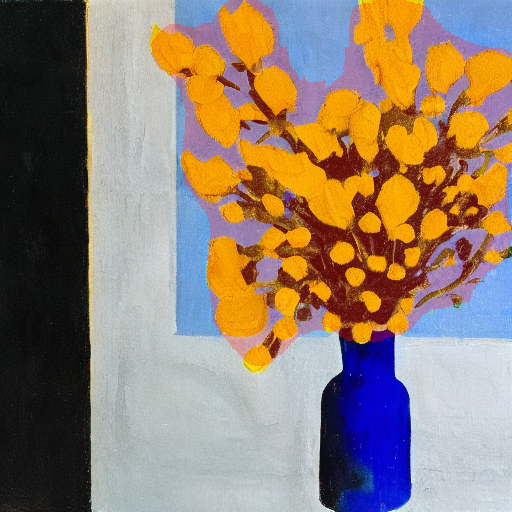

annotations/sd15/attribute_color_seed_0000/preview/vase_overlay.png


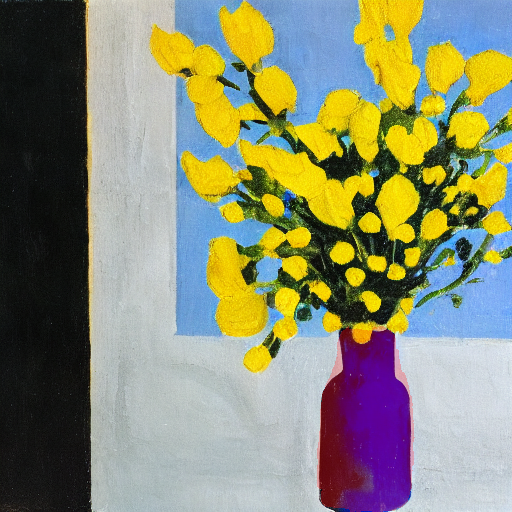

annotations/sd15/attribute_color_seed_0001/preview/flowers_overlay.png


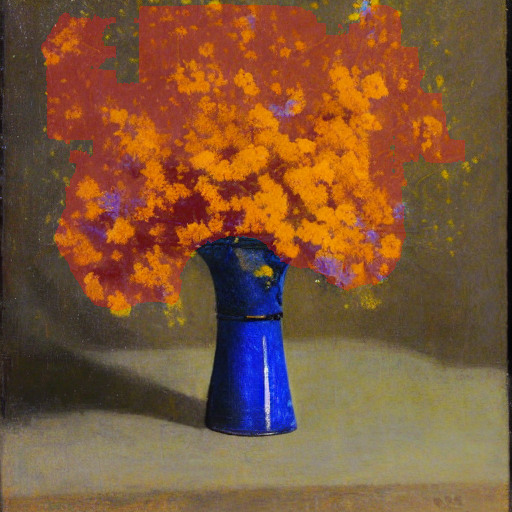

annotations/sd15/attribute_color_seed_0001/preview/vase_overlay.png


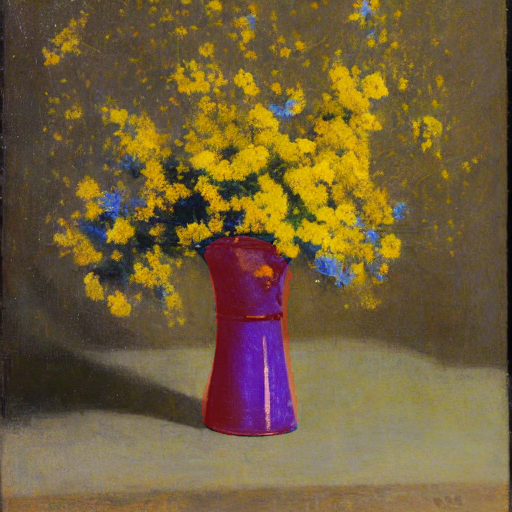

annotations/sd15/cat_chair_seed_0000/preview/cat_overlay.png


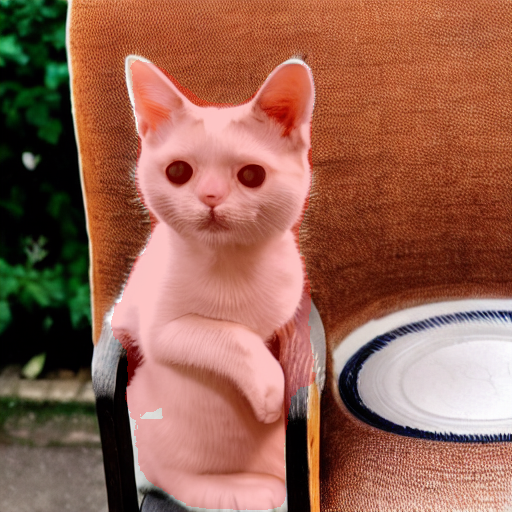

annotations/sd15/cat_chair_seed_0000/preview/chair_overlay.png


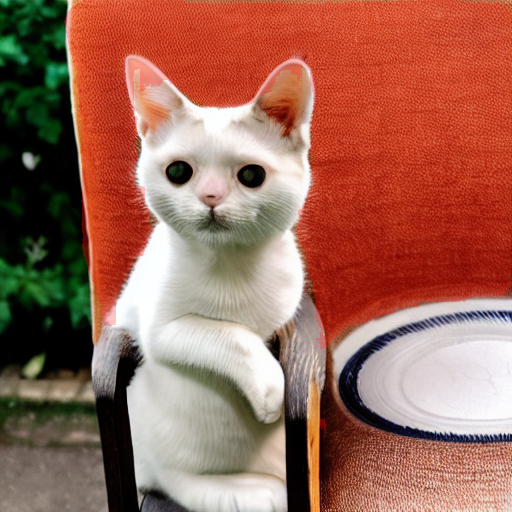

annotations/sd15/cat_chair_seed_0001/preview/cat_overlay.png


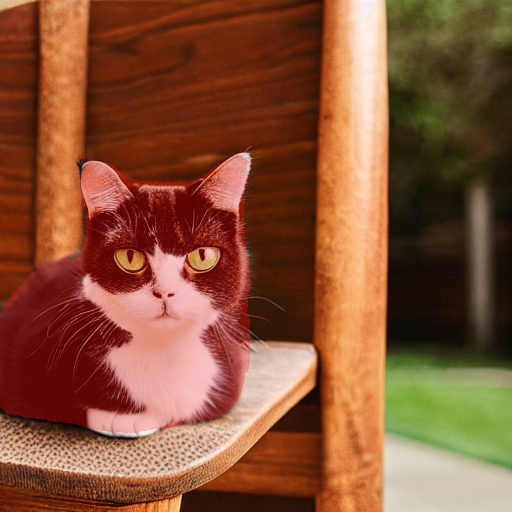

annotations/sd15/cat_chair_seed_0001/preview/chair_overlay.png


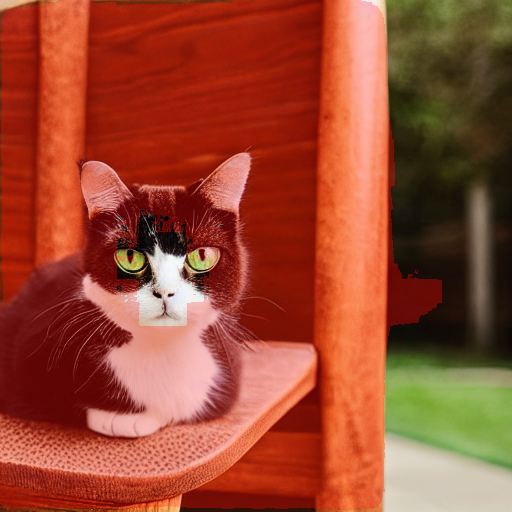

annotations/sd15/person_umbrella_seed_0000/preview/person_overlay.png


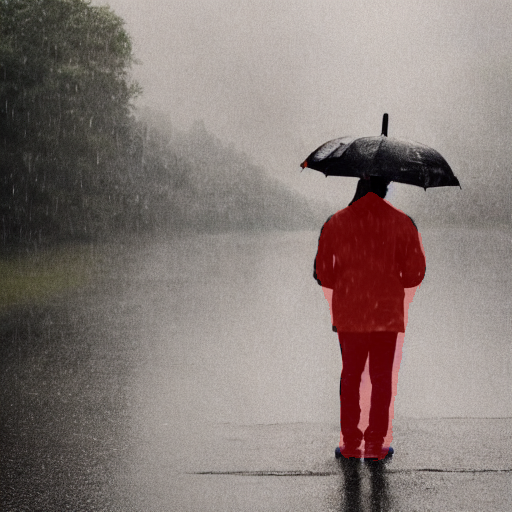

annotations/sd15/person_umbrella_seed_0000/preview/umbrella_overlay.png


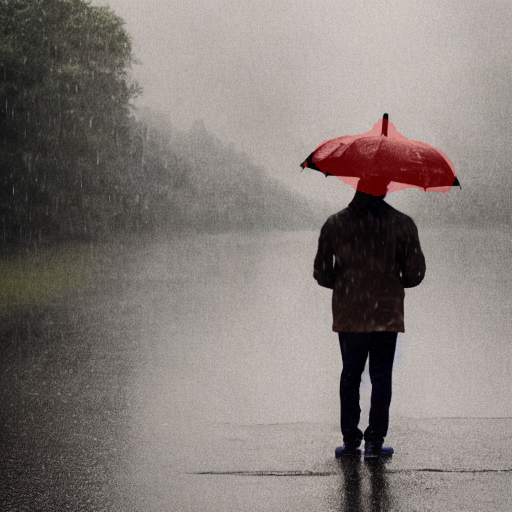

annotations/sd15/person_umbrella_seed_0001/preview/person_overlay.png


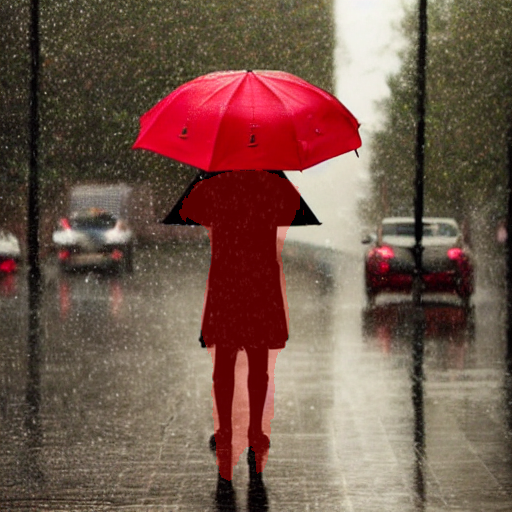

annotations/sd15/person_umbrella_seed_0001/preview/umbrella_overlay.png


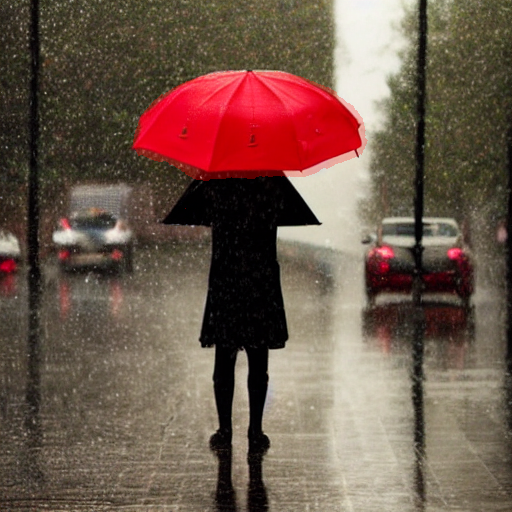

annotations/sd15/rare_composition_seed_0000/preview/bench_overlay.png


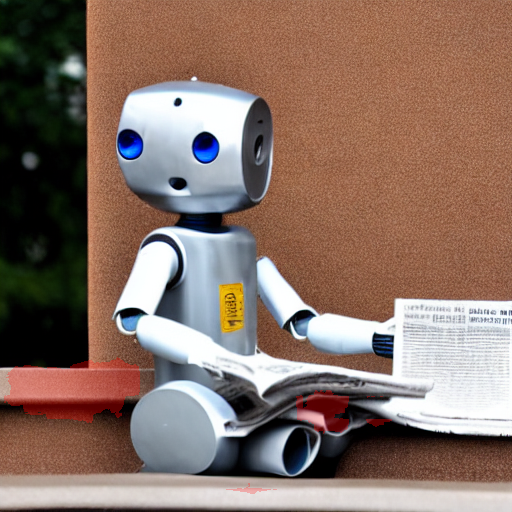

annotations/sd15/rare_composition_seed_0000/preview/newspaper_overlay.png


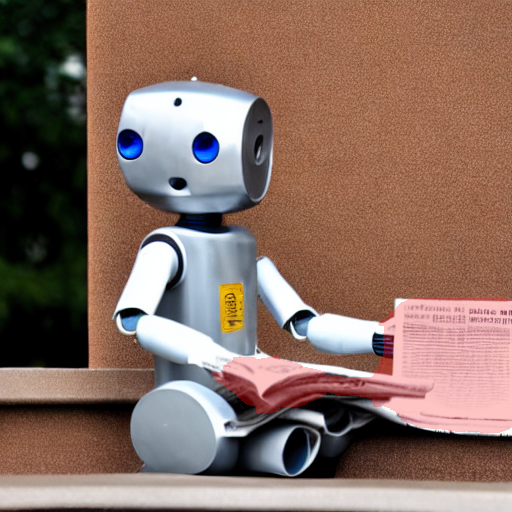

annotations/sd15/rare_composition_seed_0000/preview/robot_overlay.png


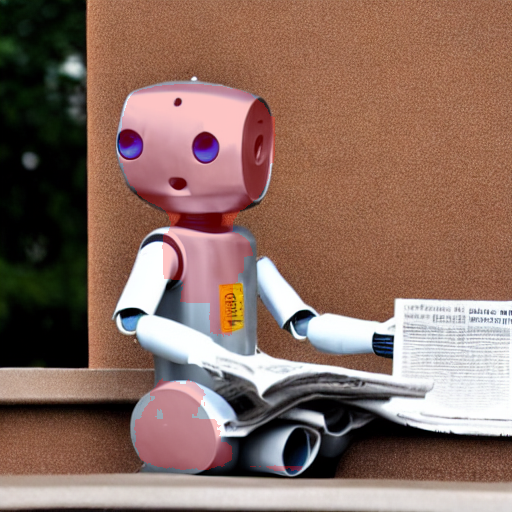

annotations/sd15/rare_composition_seed_0001/preview/bench_overlay.png


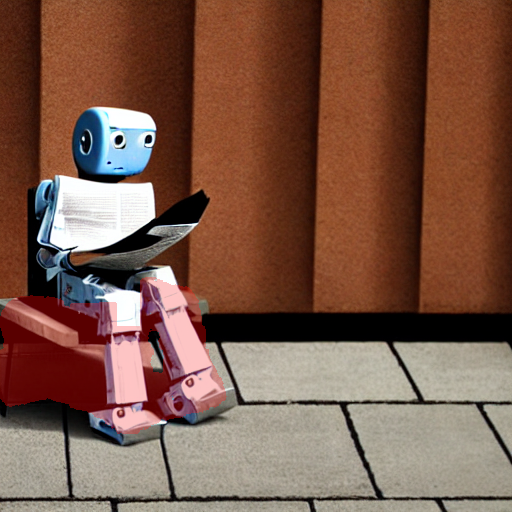

In [36]:
from pathlib import Path
from IPython.display import Image, display

preview_paths = sorted((PROJECT_ROOT / "annotations/sd15").glob("*/preview/*_overlay.png"))

print("Preview overlays:", len(preview_paths))

for p in preview_paths[:16]:
    print(p.relative_to(PROJECT_ROOT))
    display(Image(filename=str(p), width=256))

### detect available attention steps

In [37]:
from pathlib import Path

capture_dir = PROJECT_ROOT / "outputs/sd15/01_capture/captures"

AVAILABLE_STEPS = sorted({
    int(p.parent.name.split("_")[-1])
    for p in capture_dir.glob("*/attention/step_*/*.pt")
})

REQUESTED_STEPS = [0, 24, 49]
USABLE_STEPS = [s for s in REQUESTED_STEPS if s in AVAILABLE_STEPS]

print("Available attention steps:", AVAILABLE_STEPS)
print("Requested Stage-2 steps:", REQUESTED_STEPS)
print("Usable Stage-2 steps:", USABLE_STEPS)

assert AVAILABLE_STEPS, "No attention files found. Stage 1 did not save attention maps."
assert USABLE_STEPS, "None of the requested Stage-2 steps are available."

STAGE2_OVERRIDES = [f"metrics.steps={USABLE_STEPS}"]

if 49 not in AVAILABLE_STEPS:
    print("Note: step_049 is not present. Stage 2 will use available steps only.")

Available attention steps: [0, 24, 49]
Requested Stage-2 steps: [0, 24, 49]
Usable Stage-2 steps: [0, 24, 49]


### attention localization

In [38]:
run_config(
    "configs/02_attention_localization/sd15_full.yaml",
    overrides=STAGE2_OVERRIDES,
)

show_report("outputs/sd15/02_attention_localization/report.json")

$ /usr/local/bin/python3 -m diffusion_attention_analysis_v2.cli.run_stage --config configs/02_attention_localization/sd15_full.yaml --override metrics.steps=[0, 24, 49]


attention localization started:   0%|          | 0/288 [00:00<?, ?it/s]

attention files processed {'stage_id': '02_attention_localization_sd15_full', 'time_sec': 11.402, 'total': 288, 'current': 32}
attention files processed {'stage_id': '02_attention_localization_sd15_full', 'time_sec': 12.52, 'total': 288, 'current': 64}
attention files processed {'stage_id': '02_attention_localization_sd15_full', 'time_sec': 13.571, 'total': 288, 'current': 96}
attention files processed {'stage_id': '02_attention_localization_sd15_full', 'time_sec': 14.642, 'total': 288, 'current': 128}
attention files processed {'stage_id': '02_attention_localization_sd15_full', 'time_sec': 15.802, 'total': 288, 'current': 160}
attention files processed {'stage_id': '02_attention_localization_sd15_full', 'time_sec': 16.77, 'total': 288, 'current': 192}
attention files processed {'stage_id': '02_attention_localization_sd15_full', 'time_sec': 17.77, 'total': 288, 'current': 224}
attention files processed {'stage_id': '02_attention_localization_sd15_full', 'time_sec': 18.792, 'total': 288

<ml_kernel._vendor.IPython.core.display.JSON object>

<ml_kernel._vendor.IPython.core.display.JSON object>

{'status': 'ok',
 'rows': 612,
 'skipped': {'missing_metadata': 0,
  'missing_annotation': 0,
  'missing_token': 0,
  'non_cross': 0},
 'summary': {'iou_mean': 0.28443618257713904,
  'iou_std': 0.21076463733226297,
  'iou_n': 612,
  'centroid_distance_mean': 2.88304703786675,
  'centroid_distance_std': 1.7879159492618188,
  'centroid_distance_n': 609,
  'entropy_mean': 0.9001779021764216,
  'entropy_std': 0.061520539276806,
  'entropy_n': 612}}

### metrics

In [39]:
import pandas as pd
from IPython.display import display

rows_path = PROJECT_ROOT / "outputs/sd15/02_attention_localization/attention_localization_rows.csv"
assert rows_path.exists(), rows_path

loc_df = pd.read_csv(rows_path)

print("Localization rows:", len(loc_df))
display(loc_df.head(30))

if len(loc_df):
    display(
        loc_df.groupby("step")[["iou", "centroid_distance", "entropy"]]
        .mean()
        .reset_index()
    )

    display(
        loc_df.groupby("label")[["iou", "centroid_distance", "entropy"]]
        .mean()
        .sort_values("iou", ascending=False)
        .reset_index()
    )

Localization rows: 612


,sample_id,label,step,layer,iou,centroid_distance,entropy,num_token_indices
0,attribute_color_seed_0000,flowers,0,down_blocks.2.attentions.0.transformer_blocks....,0.482143,2.556586,0.941944,1
1,attribute_color_seed_0000,vase,0,down_blocks.2.attentions.0.transformer_blocks....,0.000000,5.609756,0.934659,2
2,attribute_color_seed_0000,flowers,0,down_blocks.2.attentions.1.transformer_blocks....,0.455446,2.137543,0.887225,1
3,attribute_color_seed_0000,vase,0,down_blocks.2.attentions.1.transformer_blocks....,0.116279,5.887725,0.947642,2
4,attribute_color_seed_0000,flowers,0,mid_block.attentions.0.transformer_blocks.0.at...,0.344828,1.945033,0.933530,1
5,attribute_color_seed_0000,vase,0,mid_block.attentions.0.transformer_blocks.0.at...,0.069767,2.465292,0.959704,2
6,attribute_color_seed_0000,flowers,0,up_blocks.1.attentions.0.transformer_blocks.0....,0.465347,2.660634,0.910361,1
7,attribute_color_seed_0000,vase,0,up_blocks.1.attentions.0.transformer_blocks.0....,0.160714,5.145470,0.928330,2
8,attribute_color_seed_0000,flowers,0,up_blocks.1.attentions.1.transformer_blocks.0....,0.477064,2.013186,0.903416,1
9,attribute_color_seed_0000,vase,0,up_blocks.1.attentions.1.transformer_blocks.0....,0.121622,5.490684,0.946612,2


,step,iou,centroid_distance,entropy
0,0,0.247902,3.310581,0.937696
1,24,0.314971,2.699095,0.881869
2,49,0.290435,2.639465,0.880969


,label,iou,centroid_distance,entropy
0,grass,0.420642,2.352730,0.935081
1,flowers,0.411085,1.901196,0.905154
2,car,0.402991,2.137982,0.882242
3,cat,0.385465,1.597502,0.865135
4,vase,0.363667,3.024863,0.899923
5,book,0.349171,2.350956,0.933630
6,dog,0.341483,1.972153,0.867423
7,bicycle,0.309097,1.957708,0.893490
8,umbrella,0.295916,2.974295,0.880591
9,newspaper,0.266194,3.528526,0.884124


## Stage 3 — SAE training

In [ ]:
run_config("configs/03_sae_training/sd15_full.yaml", overrides=SAE_OVERRIDES)
show_report("outputs/sd15/03_sae_mid/report.json")

## Stage 4 — concept dictionary

Requires masks and a trained SAE.

In [ ]:
run_config("configs/04_concept_dictionary/sd15_full.yaml", overrides=(["dictionary.max_activation_files=32"] if SMOKE_TEST else []))
show_report("outputs/sd15/04_concept_dictionary/report.json")

## Stage 5a — map-level intervention

In [ ]:
run_config("configs/05_interventions/sd15_map_reweight.yaml", overrides=INTERVENTION_OVERRIDES)
show_report("outputs/sd15/05_intervention_map_reweight/report.json")

## Stage 5b — SAE steering

In [ ]:
run_config("configs/05_interventions/sd15_sae_steering.yaml", overrides=INTERVENTION_OVERRIDES)
show_report("outputs/sd15/05_intervention_sae_steering/report.json")